# Setting up Spark and MongoDB

In [1]:
#Pre-Reqs to read and write from mongoDB
#Run it in Google Colab

!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget --show-progress https://mirrors.huaweicloud.com/apache/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz -O spark.tgz
!tar -xzf spark.tgz
!pip install -q pyspark==3.5.1

import os
from pyspark.sql import SparkSession

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["SPARK_HOME"], "bin")

--2026-05-07 15:04:24--  https://mirrors.huaweicloud.com/apache/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
Resolving mirrors.huaweicloud.com (mirrors.huaweicloud.com)... 124.70.61.162, 123.249.118.101, 120.46.63.139, ...
Connecting to mirrors.huaweicloud.com (mirrors.huaweicloud.com)|124.70.61.162|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400446614 (382M) [application/octet-stream]
Saving to: ‘spark.tgz’

spark.tgz           100%[===================>] 381.90M  3.82MB/s    in 62s     

2026-05-07 15:05:28 (6.15 MB/s) - ‘spark.tgz’ saved [400446614/400446614]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 8.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 

### Initialize Spark Context

In [ ]:
## CUSTOMIZE YOUR CREDENTIALS AS PER YOUR SETTING
!pip install findspark
import findspark
findspark.init()

#Replace MongoDB URI

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HubwayBikeETL") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .config("spark.mongodb.read.connection.uri",
            "<MONGODB-URI>") \
    .config("spark.mongodb.write.connection.uri",
            "<MONGODB-URI>") \
    .getOrCreate()

## YOUR ETL PIPELINE TASK

### Step 1: Data Preparation

- Load the provided Trips and Stations Data into Spark DataFrame.

## DATASET : BIKE SHARING DATA

Trips: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/bike-data/201508_trip_data.csv

Stations: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/bike-data/201508_station_data.csv

Zip_Code_Map: https://raw.githubusercontent.com/scpike/us-state-county-zip/master/geo-data.csv

## Reading Data from CSV

In [50]:
from pyspark import SparkFiles

#Reading Trips Data into Dataframe

url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/bike-data/201508_trip_data.csv"
spark.sparkContext.addFile(url)

trips_df=spark.read.csv(SparkFiles.get("201508_trip_data.csv"),header=True,multiLine=True, escape='"')

In [51]:
trips_df.printSchema()

root
 |-- Trip ID: string (nullable = true)
 |-- Duration: string (nullable = true)
 |-- Start Date: string (nullable = true)
 |-- Start Station: string (nullable = true)
 |-- Start Terminal: string (nullable = true)
 |-- End Date: string (nullable = true)
 |-- End Station: string (nullable = true)
 |-- End Terminal: string (nullable = true)
 |-- Bike #: string (nullable = true)
 |-- Subscriber Type: string (nullable = true)
 |-- Zip Code: string (nullable = true)



In [52]:
## CORRECTING COLUMN NAME FORMAT SINCE IT WILL BE HARD TO HAND SPACED COLUMN NAMES IN SPARK

import pyspark.sql.functions as F

def correct_headers(df):
  return df.select([F.col(col).alias(col.replace(' ', '_')) for col in df.columns])

## USE THIS FUNCTION TO CORRECT HEADERS AND PROCEED WITH YOUR ETL PIPELINE

In [53]:
trips_df = correct_headers(trips_df)
trips_df.printSchema()

root
 |-- Trip_ID: string (nullable = true)
 |-- Duration: string (nullable = true)
 |-- Start_Date: string (nullable = true)
 |-- Start_Station: string (nullable = true)
 |-- Start_Terminal: string (nullable = true)
 |-- End_Date: string (nullable = true)
 |-- End_Station: string (nullable = true)
 |-- End_Terminal: string (nullable = true)
 |-- Bike_#: string (nullable = true)
 |-- Subscriber_Type: string (nullable = true)
 |-- Zip_Code: string (nullable = true)



In [54]:
trips_df.show(20)

+-------+--------+---------------+--------------------+--------------+---------------+--------------------+------------+------+---------------+--------+
|Trip_ID|Duration|     Start_Date|       Start_Station|Start_Terminal|       End_Date|         End_Station|End_Terminal|Bike_#|Subscriber_Type|Zip_Code|
+-------+--------+---------------+--------------------+--------------+---------------+--------------------+------------+------+---------------+--------+
| 913460|     765|8/31/2015 23:26|Harry Bridges Pla...|            50|8/31/2015 23:39|San Francisco Cal...|          70|   288|     Subscriber|    2139|
| 913459|    1036|8/31/2015 23:11|San Antonio Shopp...|            31|8/31/2015 23:28|Mountain View Cit...|          27|    35|     Subscriber|   95032|
| 913455|     307|8/31/2015 23:13|      Post at Kearny|            47|8/31/2015 23:18|   2nd at South Park|          64|   468|     Subscriber|   94107|
| 913454|     409|8/31/2015 23:10|  San Jose City Hall|            10|8/31/2015 23

In [55]:
#Reading Station Data into Dataframe

url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/bike-data/201508_station_data.csv"
spark.sparkContext.addFile(url)

stations_df=spark.read.csv(SparkFiles.get("201508_station_data.csv"),header=True,multiLine=True, escape='"')

stations_df.printSchema()

## USE THE FUNCTION CORRECT HEADERS TO CORRECT STATION HEADERS AND PROCEED WITH YOUR ETL PIPELINE

root
 |-- station_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- long: string (nullable = true)
 |-- dockcount: string (nullable = true)
 |-- landmark: string (nullable = true)
 |-- installation: string (nullable = true)



In [56]:
#Reading ZipCode Data into Dataframe

url = "https://raw.githubusercontent.com/scpike/us-state-county-zip/master/geo-data.csv"
spark.sparkContext.addFile(url)

Zip_Code_Map=spark.read.csv(SparkFiles.get("geo-data.csv"),header=True,multiLine=True, escape='"')

Zip_Code_Map.printSchema()

## USE THE FUNCTION CORRECT HEADERS TO CORRECT STATION HEADERS AND PROCEED WITH YOUR ETL PIPELINE

root
 |-- state_fips: string (nullable = true)
 |-- state: string (nullable = true)
 |-- state_abbr: string (nullable = true)
 |-- zipcode: string (nullable = true)
 |-- county: string (nullable = true)
 |-- city: string (nullable = true)



### Step 2: Data Transformation

- Join the Trips DataFrame with the Stations DataFrame to add Starting Landmark and Ending Landmark columns. (You will require same station to be joined to trips table twice with different joining conditions)
- Use the Zip Code Mapping dataset to add a “State” column to the Trips DataFrame, based on the available Zip Code field.
- Extract the Month_Year from the Start Date.
- Select Relevant Columns Required leave the rest

In [57]:
from pyspark.sql.functions import col, when

In [58]:
trips_df = trips_df.join(stations_df.select(col("station_id").alias("Start_Terminal"), col("Landmark").alias("Starting_Landmark")), on="Start_Terminal",how="left")
trips_df.show(5)

+--------------+-------+--------+---------------+--------------------+---------------+--------------------+------------+------+---------------+--------+-----------------+
|Start_Terminal|Trip_ID|Duration|     Start_Date|       Start_Station|       End_Date|         End_Station|End_Terminal|Bike_#|Subscriber_Type|Zip_Code|Starting_Landmark|
+--------------+-------+--------+---------------+--------------------+---------------+--------------------+------------+------+---------------+--------+-----------------+
|            50| 913460|     765|8/31/2015 23:26|Harry Bridges Pla...|8/31/2015 23:39|San Francisco Cal...|          70|   288|     Subscriber|    2139|    San Francisco|
|            31| 913459|    1036|8/31/2015 23:11|San Antonio Shopp...|8/31/2015 23:28|Mountain View Cit...|          27|    35|     Subscriber|   95032|    Mountain View|
|            47| 913455|     307|8/31/2015 23:13|      Post at Kearny|8/31/2015 23:18|   2nd at South Park|          64|   468|     Subscriber|  

In [59]:
trips_df = trips_df.join(stations_df.select(col("station_id").alias("End_Terminal"), col("Landmark").alias("Ending_Landmark")), on="End_Terminal",how="left")
trips_df.show(5)

+------------+--------------+-------+--------+---------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+
|End_Terminal|Start_Terminal|Trip_ID|Duration|     Start_Date|       Start_Station|       End_Date|         End_Station|Bike_#|Subscriber_Type|Zip_Code|Starting_Landmark|Ending_Landmark|
+------------+--------------+-------+--------+---------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+
|          70|            50| 913460|     765|8/31/2015 23:26|Harry Bridges Pla...|8/31/2015 23:39|San Francisco Cal...|   288|     Subscriber|    2139|    San Francisco|  San Francisco|
|          27|            31| 913459|    1036|8/31/2015 23:11|San Antonio Shopp...|8/31/2015 23:28|Mountain View Cit...|    35|     Subscriber|   95032|    Mountain View|  Mountain View|
|          64|            47| 913455|     307|8/31/2015 23:13|   

In [60]:
trips_df = trips_df.alias("t").join(Zip_Code_Map.alias("zc"),col("t.Zip_Code") == col("zc.zipcode"),how="left")
trips_df.filter(col("Subscriber_Type") == "Customer").show(5)

+------------+--------------+-------+--------+---------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+----------+------------+----------+-------+------------+------------+
|End_Terminal|Start_Terminal|Trip_ID|Duration|     Start_Date|       Start_Station|       End_Date|         End_Station|Bike_#|Subscriber_Type|Zip_Code|Starting_Landmark|Ending_Landmark|state_fips|       state|state_abbr|zipcode|      county|        city|
+------------+--------------+-------+--------+---------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+----------+------------+----------+-------+------------+------------+
|          60|            51| 913453|     789|8/31/2015 23:09|Embarcadero at Fo...|8/31/2015 23:22|Embarcadero at Sa...|   487|       Customer|    9069|    San Francisco|  San Francisco|      NULL|        NULL|      NULL|   NULL|   

In [61]:
trips_df = trips_df.withColumn("state", when(col("zc.state").isNull(), "Unknown").otherwise(col("zc.state")))
trips_df = trips_df.drop(col("zc.zipcode"), col("zc.state"))
trips_df.filter(col("Subscriber_Type") == "Customer").select("Zip_Code", "state", "Subscriber_Type").show(5)


+--------+------------+---------------+
|Zip_Code|       state|Subscriber_Type|
+--------+------------+---------------+
|    9069|     Unknown|       Customer|
|   92562|  California|       Customer|
|    6907|     Unknown|       Customer|
|   43214|        Ohio|       Customer|
|   19127|Pennsylvania|       Customer|
+--------+------------+---------------+
only showing top 5 rows



In [62]:
from pyspark.sql.functions import to_timestamp, date_format

trips_df = trips_df.withColumn("Start_Date", to_timestamp("Start_Date", "M/d/yyyy HH:mm"))
trips_df = trips_df.withColumn("Month_Year", date_format("Start_Date", "MM-yyyy"))
trips_df.show(5)

+------------+--------------+-------+--------+-------------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+----------+----------+----------+-------------+-------------+----------+
|End_Terminal|Start_Terminal|Trip_ID|Duration|         Start_Date|       Start_Station|       End_Date|         End_Station|Bike_#|Subscriber_Type|Zip_Code|Starting_Landmark|Ending_Landmark|state_fips|     state|state_abbr|       county|         city|Month_Year|
+------------+--------------+-------+--------+-------------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+----------+----------+----------+-------------+-------------+----------+
|          70|            50| 913460|     765|2015-08-31 23:26:00|Harry Bridges Pla...|8/31/2015 23:39|San Francisco Cal...|   288|     Subscriber|    2139|    San Francisco|  San Francisco|      NULL|   Unknown

In [64]:
trips_df.select("Trip_ID", "Duration","Start_Date","Start_Station", "End_Date","End_Station","Bike_#","Subscriber_Type","Zip_Code","Starting_Landmark","Ending_Landmark","state","county","city","Month_Year").show(5)

+-------+--------+-------------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+----------+-------------+-------------+----------+
|Trip_ID|Duration|         Start_Date|       Start_Station|       End_Date|         End_Station|Bike_#|Subscriber_Type|Zip_Code|Starting_Landmark|Ending_Landmark|     state|       county|         city|Month_Year|
+-------+--------+-------------------+--------------------+---------------+--------------------+------+---------------+--------+-----------------+---------------+----------+-------------+-------------+----------+
| 913460|     765|2015-08-31 23:26:00|Harry Bridges Pla...|8/31/2015 23:39|San Francisco Cal...|   288|     Subscriber|    2139|    San Francisco|  San Francisco|   Unknown|         NULL|         NULL|   08-2015|
| 913459|    1036|2015-08-31 23:11:00|San Antonio Shopp...|8/31/2015 23:28|Mountain View Cit...|    35|     Subscriber|   95032|    Mountain View|  

### Step 3: Data Aggregation

- Group the DataFrame by Starting Landmark, Ending Landmark, State, Subscriber Type, and Month_Year.
- Calculate the following measures:
  - Number_of_Trips (count distinct Trip_ID)
  - Duration_Total_Minutes (sum of Duration) / 60

In [65]:
from pyspark.sql.functions import col, countDistinct, sum, round
from pyspark.sql.functions import when

In [68]:
agg_df = trips_df.groupBy("Starting_Landmark","Ending_Landmark", "State","Subscriber_Type","Month_Year").agg(countDistinct("Trip_ID").alias("Number_of_Trips"),round((sum("Duration") / 60), 2).alias("Duration_Total_Minutes"))

In [71]:
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
agg_df.show(20)

+-----------------+---------------+--------------------+---------------+----------+---------------+----------------------+
|Starting_Landmark|Ending_Landmark|               State|Subscriber_Type|Month_Year|Number_of_Trips|Duration_Total_Minutes|
+-----------------+---------------+--------------------+---------------+----------+---------------+----------------------+
|         San Jose|       San Jose|               Texas|       Customer|   06-2015|              3|                114.87|
|        Palo Alto|      Palo Alto|            Illinois|       Customer|   05-2015|              2|                150.22|
|        Palo Alto|      Palo Alto|District of columbia|       Customer|   03-2015|              3|                129.33|
|    San Francisco|  San Francisco|               Idaho|       Customer|   04-2015|              2|                279.25|
|        Palo Alto|      Palo Alto|           Minnesota|       Customer|   01-2015|              4|                101.37|
|    San Francis

### Step 4: Save the Data in MongoDB for Analytics Later


In [ ]:
agg_df.write.format("mongodb") \
    .option("database", "DBname") \
    .option("collection", "col_name") \
    .mode("overwrite") \
    .save()

In [ ]:
df_read = spark.read.format("mongodb") \
    .option("database", "DBname") \
    .option("collection", "Col_name") \
    .load()

df_read.show(20)

+----------------------+---------------+----------+---------------+-----------------+--------------------+---------------+--------------------+
|Duration_Total_Minutes|Ending_Landmark|Month_Year|Number_of_Trips|Starting_Landmark|               State|Subscriber_Type|                 _id|
+----------------------+---------------+----------+---------------+-----------------+--------------------+---------------+--------------------+
|                114.87|       San Jose|   06-2015|              3|         San Jose|               Texas|       Customer|69fcc749a38ea4398...|
|                150.22|      Palo Alto|   05-2015|              2|        Palo Alto|            Illinois|       Customer|69fcc749a38ea4398...|
|                129.33|      Palo Alto|   03-2015|              3|        Palo Alto|District of columbia|       Customer|69fcc749a38ea4398...|
|                279.25|  San Francisco|   04-2015|              2|    San Francisco|               Idaho|       Customer|69fcc749a38ea4

#### Outcome Dataframe

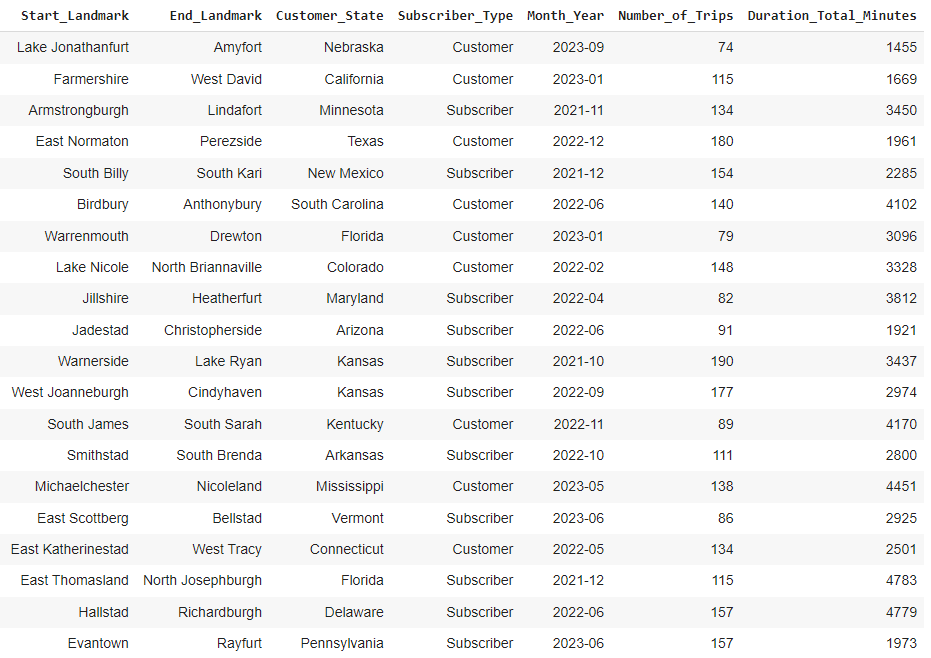